In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!pip install optuna

In [11]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# --- CONFIGURAÇÕES GLOBAIS ---
RANDOM_STATE = 42
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/pamap2_v2.npz' #lsc
N_BOOTSTRAP_ITERATIONS = 1000

In [12]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO
# ==========================================

def load_data_and_split(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']
    except FileNotFoundError:
        print(" Erro: Arquivo .npz não encontrado.")
        return None

    print(f"   Shape Treino Original: {X_train.shape}")

    # Retorna as 3 partições  (Subject-Independent)
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def prep_data(X, mode='raw'):
    if mode == 'raw':
        return X.reshape(X.shape[0], -1)
    elif mode == 'features':
        return np.hstack([
            np.mean(X, axis=1), np.std(X, axis=1),
            np.max(X, axis=1), np.min(X, axis=1)
        ])
    return X


In [13]:
# ==========================================
# 2. OTIMIZAÇÃO (OPTUNA FAST)
# ==========================================

def run_optuna_rf(X_tr, y_tr, X_val, y_val, mode_name):
    def objective(trial):
        # Hiperparâmetros
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)

        # Para permitir a escolha entre None ou um Range numérico:
        max_depth_choice = trial.suggest_categorical('max_depth_choice', ['none', 'int'])
        if max_depth_choice == 'none':
            max_depth = None
        else:
            max_depth = trial.suggest_int('max_depth', 10, 50)

        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

        # Tratamento de Classes via Optuna
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        return f1_score(y_val, preds, average='macro')

    print(f"\n [Optuna] Otimizando RF: {mode_name}...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Configurando o sampler com seed fixa para reprodutibilidade
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=50)

    print(f"   Best Params (Raw): {study.best_params}")

    # Limpando os parâmetros auxiliares para evitar erros ao injetar via **params
    best_p = study.best_params.copy()
    if best_p.get('max_depth_choice') == 'none':
        best_p['max_depth'] = None
    if 'max_depth_choice' in best_p:
        del best_p['max_depth_choice']

    return best_p


In [14]:
# ==========================================
# 3. EXPERIMENTOS (BOOTSTRAP)
# ==========================================

def run_experiments_rf(X_train, y_train, X_test, y_test, params, scenario_name):

    # Configuração
    if params == 'balanced':
        model = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:
        # Modelo Otimizado (recebendo os hiperparâmetros diretamente via **params)
        model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

    # Treinamento e Inferência Inicial (necessário para a Matriz e o Bootstrap)
    print(f"\n [Treinamento] Ajustando modelo: {scenario_name}...")
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    duration = time.time() - start
    print(f"   Tempo de Treinamento/Inferência: {duration:.2f}s")

    #  MATRIZ DE CONFUSÃO
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues') # Tons de azul, formatação para float
    plt.title(f'Matriz de Confusão Normalizada: {scenario_name}')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.show()

    # B. Bootstrap (F1 e Acurácia)
    print(f"   Calculando métricas via Bootstrap ({N_BOOTSTRAP_ITERATIONS} iterações)...")
    f1_stats = []
    acc_stats = []
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        y_true_res, y_pred_res = resample(y_test, y_pred, random_state=None)
        f1_stats.append(f1_score(y_true_res, y_pred_res, average='macro'))
        acc_stats.append(accuracy_score(y_true_res, y_pred_res))

    return {
        'Cenário': scenario_name,
        'F1_Mean': np.mean(f1_stats),
        'F1_CI_Lower': np.percentile(f1_stats, 2.5),
        'F1_CI_Upper': np.percentile(f1_stats, 97.5),
        'Acc_Mean': np.mean(acc_stats),
        'Acc_CI_Lower': np.percentile(acc_stats, 2.5),
        'Acc_CI_Upper': np.percentile(acc_stats, 97.5)
    }


 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/pamap2_v2.npz...
   Shape Treino Original: (9136, 250, 40)

 INICIANDO: Features + Balanced

 [Treinamento] Ajustando modelo: Features + Balanced...
   Tempo de Treinamento/Inferência: 0.33s


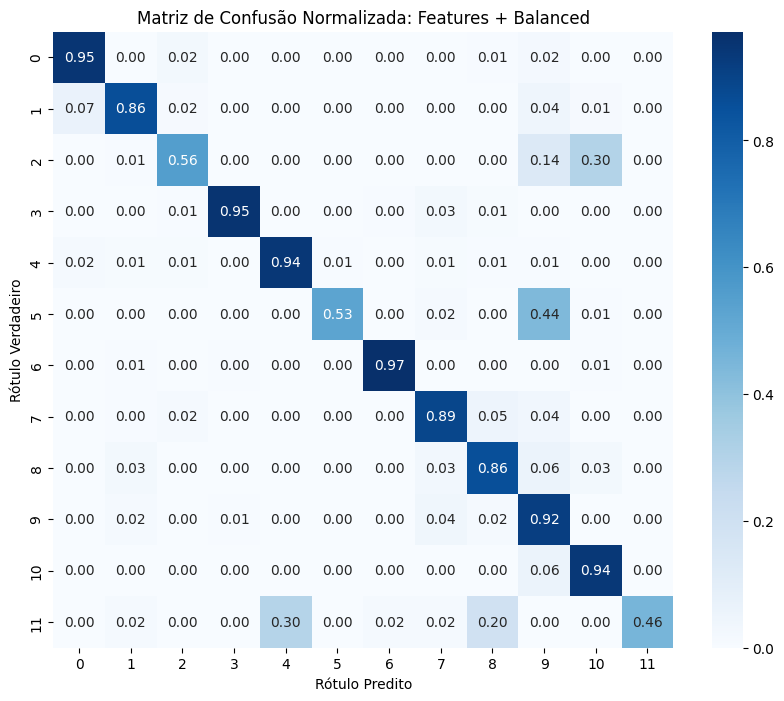

   Calculando métricas via Bootstrap (1000 iterações)...

 INICIANDO: Features + Optimized

 [Optuna] Otimizando RF: Features + Optimized...
   Best Params (Raw): {'n_estimators': 705, 'max_depth_choice': 'int', 'max_depth': 33, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}

 [Treinamento] Ajustando modelo: Features + Optimized...
   Tempo de Treinamento/Inferência: 1.40s


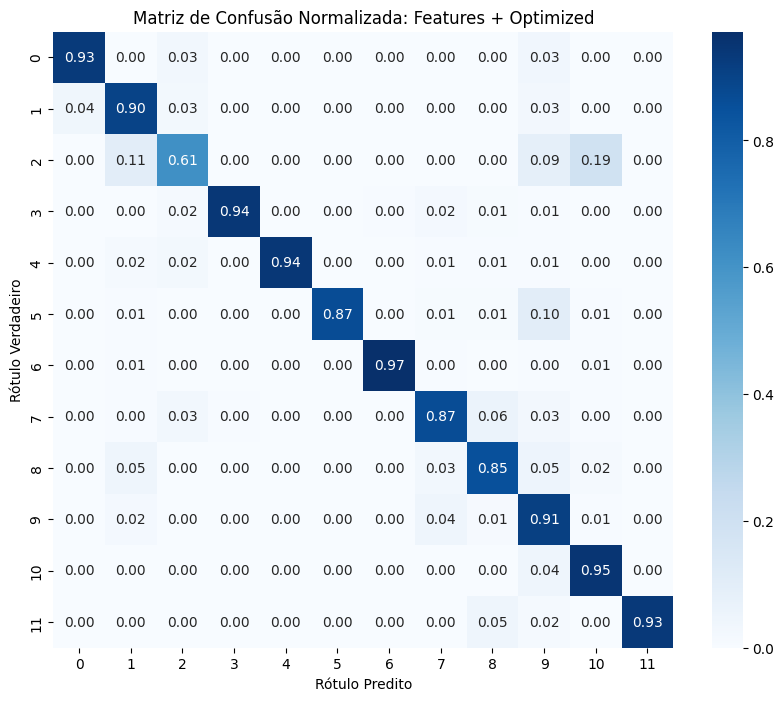

   Calculando métricas via Bootstrap (1000 iterações)...

 INICIANDO: Raw + Balanced

 [Treinamento] Ajustando modelo: Raw + Balanced...
   Tempo de Treinamento/Inferência: 2.12s


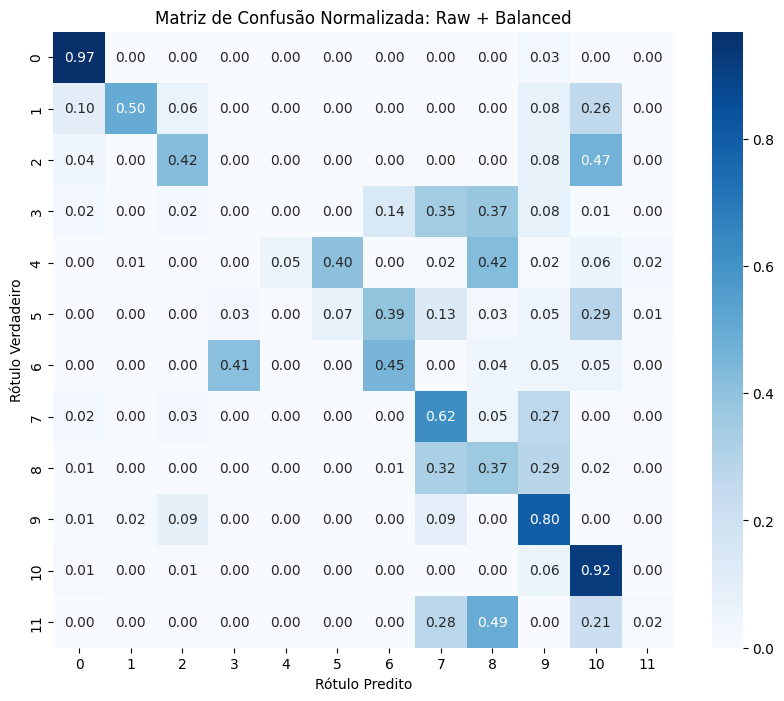

   Calculando métricas via Bootstrap (1000 iterações)...

 INICIANDO: Raw + Optimized

 [Optuna] Otimizando RF: Raw + Optimized...
   Best Params (Raw): {'n_estimators': 510, 'max_depth_choice': 'none', 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': None}

 [Treinamento] Ajustando modelo: Raw + Optimized...
   Tempo de Treinamento/Inferência: 1.17s


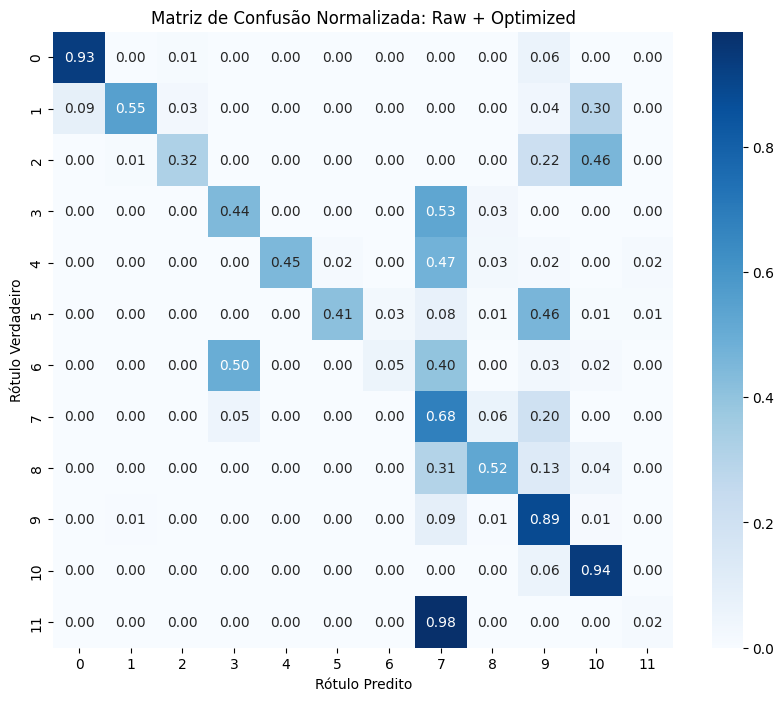

   Calculando métricas via Bootstrap (1000 iterações)...


 RELATÓRIO FINAL: RANDOM FOREST (PAMAP2) - VIA BOOTSTRAP


,Cenário,F1_Mean,F1_CI_Lower,F1_CI_Upper,Acc_Mean,Acc_CI_Lower,Acc_CI_Upper
0,Features + Balanced,0.829313,0.815971,0.843705,0.852985,0.842658,0.864141
1,Features + Optimized,0.892512,0.882592,0.902921,0.895282,0.886336,0.904923
2,Raw + Balanced,0.386075,0.373991,0.398368,0.472617,0.457288,0.487458
3,Raw + Optimized,0.507891,0.494361,0.520523,0.561428,0.546085,0.575296


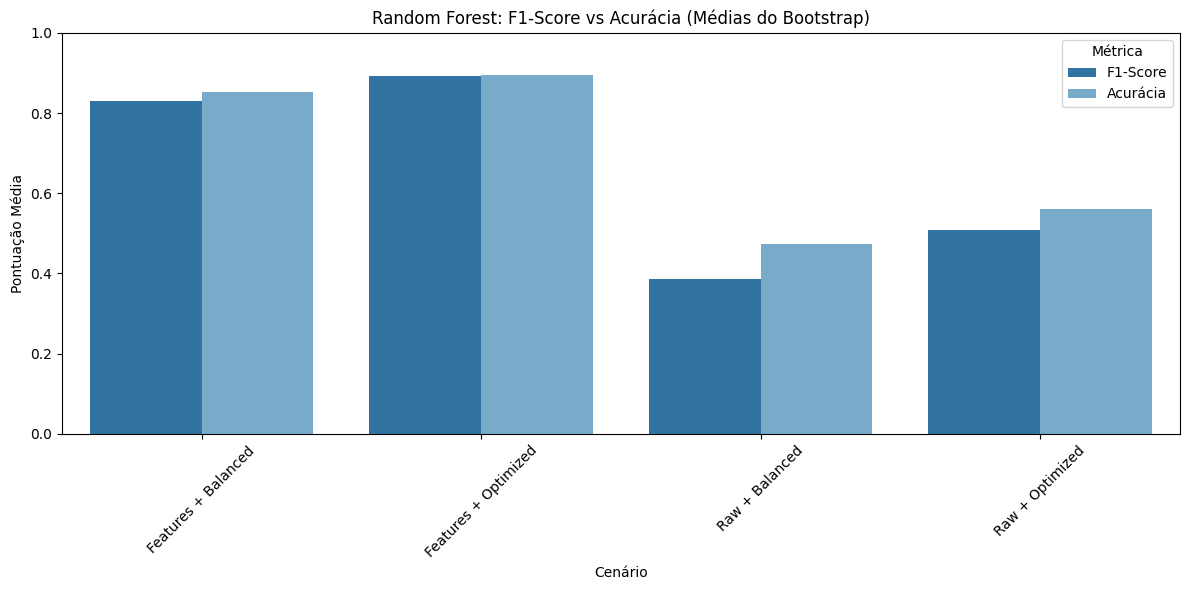

In [15]:
# ==========================================
# 4. EXECUÇÃO PRINCIPAL
# ==========================================

splits = load_data_and_split(NPZ_PATH)

if splits:
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = splits
    final_report = []

    scenarios = [
        ("Features", "balanced"),
        ("Features", "optimized"),
        ("Raw", "balanced"),
        ("Raw", "optimized")
    ]

    for data_type, param_type in scenarios:
        scenario_label = f"{data_type} + {param_type.capitalize()}"
        print(f"\n{'='*60}")
        print(f" INICIANDO: {scenario_label}")
        print(f"{'='*60}")

        mode = 'raw' if data_type == 'Raw' else 'features'

        # 1. Preparação (Faz o prep em todas as splits necessárias)
        X_tr_run = prep_data(X_train, mode)
        X_te_run = prep_data(X_test, mode)

        # 2. Otimização (Usa o X_val explicitamente)
        if param_type == 'balanced':
            best_params = 'balanced'
        else:
            X_val_run = prep_data(X_val, mode)
            best_params = run_optuna_rf(
                X_tr_run, y_train, X_val_run, y_val, scenario_label
            )
            del X_val_run # Libera memória após Optuna

        # 3. Experimentos
        res = run_experiments_rf(
            X_tr_run, y_train, X_te_run, y_test, best_params, scenario_label
        )
        final_report.append(res)

        # LIMPEZA DE MEMÓRIA (Essencial para o Raw)
        del X_tr_run, X_te_run
        gc.collect()

    # --- RELATÓRIO ---
    df_results = pd.DataFrame(final_report)
    print("\n\n RELATÓRIO FINAL: RANDOM FOREST (PAMAP2) - VIA BOOTSTRAP")
    display(df_results) # Exibe como uma tabela limpa no Colab

    # Preparando dados para o histograma azul comparativo
    df_plot = df_results.melt(id_vars=['Cenário'],
                              value_vars=['F1_Mean', 'Acc_Mean'],
                              var_name='Métrica',
                              value_name='Pontuação')

    # Renomeando para ficar mais limpo no gráfico
    df_plot['Métrica'] = df_plot['Métrica'].replace({'F1_Mean': 'F1-Score', 'Acc_Mean': 'Acurácia'})

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_plot, x='Cenário', y='Pontuação', hue='Métrica', palette=['#1f77b4', '#6baed6'])
    plt.title('Random Forest: F1-Score vs Acurácia (Médias do Bootstrap)')
    plt.ylabel('Pontuação Média')
    plt.ylim(0.0, 1.0)
    plt.xticks(rotation=45)
    plt.legend(title='Métrica')
    plt.tight_layout()
    plt.show()
else:
    print(" Falha no carregamento.")
